In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [6]:
points = np.random.randint(100, 400, 20)
points = points.reshape((-1, 2))
points.shape

(10, 2)

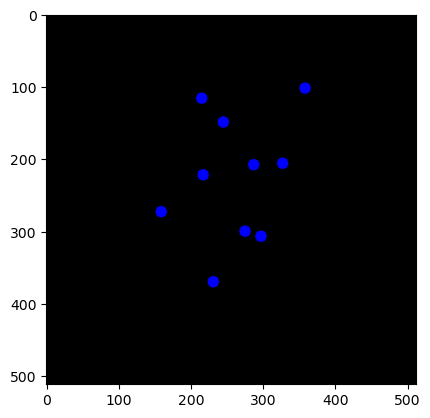

In [36]:
image = np.zeros((512, 512, 3), dtype=np.uint8)

for point in points:
    # print(point)
    cv2.circle(image, (point[0], point[1]), 8, (255, 0, 0), -1)

plt.imshow(image[..., ::-1])

In [37]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(image, 28, 255, cv2.THRESH_BINARY)
thresh = thresh.astype(np.uint8)

contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

In [49]:
for contour in contours:
    print(contour.shape)

(44, 1, 2)
(44, 1, 2)
(44, 1, 2)
(44, 1, 2)
(44, 1, 2)
(44, 1, 2)
(44, 1, 2)
(44, 1, 2)
(44, 1, 2)
(44, 1, 2)


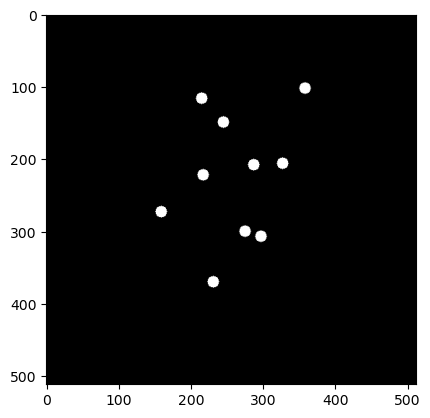

In [39]:
plt.imshow(thresh, cmap='gray')

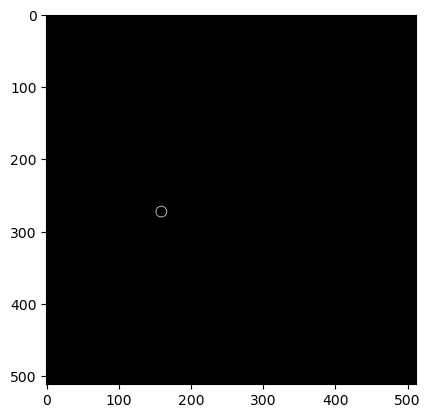

In [47]:
image_draw = np.zeros_like(image, dtype=np.uint8)

cv2.drawContours(image_draw, contours, 3, 3)

plt.imshow(image_draw, cmap='gray')

In [50]:
points_hull = cv2.convexHull(contours[0])

In [53]:
points_hull.shape

(20, 1, 2)

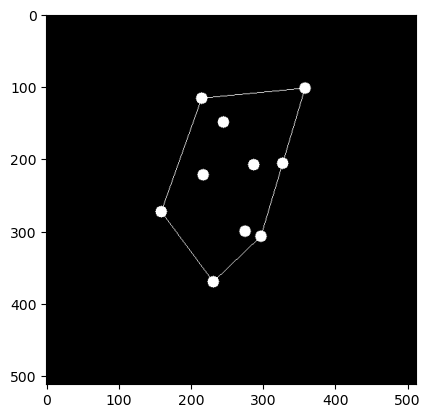

In [62]:
points_hull_2 = cv2.convexHull(points)

cv2.polylines(thresh, [points_hull_2], True, (255, 0, 0))

plt.imshow(thresh, cmap='gray')

___

In [22]:
image = cv2.imread("/mnt/e/Image processing and computer vision using OpenCV/class.vision-master/images/star.png", cv2.IMREAD_GRAYSCALE)
image.shape

(130, 117)

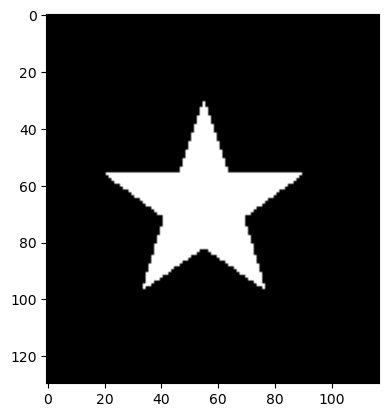

In [4]:
plt.imshow(image, cmap='gray')

In [10]:
contours_none, hierarchy = cv2.findContours(image, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
len(contours_none)

1

In [11]:
contours_none[0].shape

(232, 1, 2)

In [12]:
contours_simple, hierarchy = cv2.findContours(image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
len(contours_simple)

1

In [13]:
contours_simple[0].shape

(117, 1, 2)

In [16]:
conv_none = cv2.convexHull(contours_none[0])
conv_simple = cv2.convexHull(contours_simple[0])

print(conv_none.shape)
print(conv_simple.shape)

(5, 1, 2)
(5, 1, 2)


In [23]:
image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

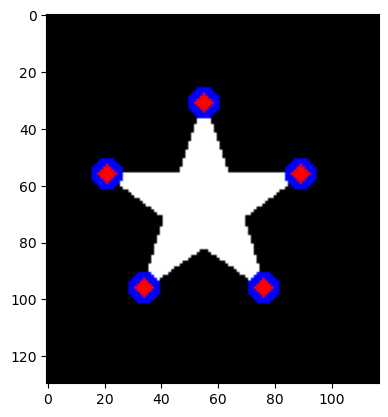

In [24]:
for i in range(conv_none.shape[0]):
    cv2.circle(image, conv_none[i][0], 3, (255, 0, 0), 3)
    cv2.circle(image, conv_simple[i][0], 1, (0, 0, 255), 3)

plt.imshow(image[..., ::-1]);

array([89, 56], dtype=int32)